In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "complaints_processed.csv"

print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Dataset path: c:\Users\rosha\NLP-Consumer-Complaint-Classification\data\complaints_processed.csv
Dataset exists: True


In [4]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (162421, 3)


,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


In [5]:
print("Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

Columns:
1. Unnamed: 0
2. product
3. narrative


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  162421 non-null  int64
 1   product     162421 non-null  str  
 2   narrative   162411 non-null  str  
dtypes: int64(1), str(2)
memory usage: 97.3 MB


In [7]:
missing = df.isnull().sum()

print("Columns with missing values:")
print(missing[missing > 0])

Columns with missing values:
narrative    10
dtype: int64


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,162421.0,NaN,NaN,NaN,81210.0,46887.048373,0.0,40605.0,81210.0,121815.0,162420.0
product,162421,5,credit_reporting,91179,NaN,NaN,NaN,NaN,NaN,NaN,NaN
narrative,162411,124472,victim identity notified collection creditor s...,739,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Check the updated dataset
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (162421, 2)


,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


In [11]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
product       0
narrative    10
dtype: int64


In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 37742


In [13]:
print("Number of complaint categories:", df["product"].nunique())
print("\nComplaint categories:")
print(df["product"].value_counts())

Number of complaint categories: 5

Complaint categories:
product
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64


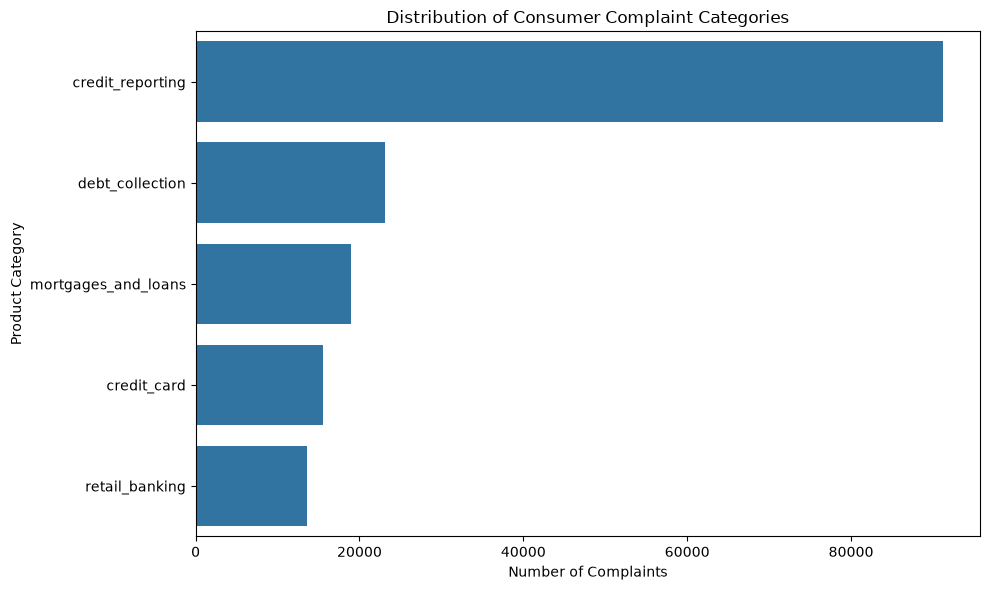

In [14]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="product",
    order=df["product"].value_counts().index
)

plt.title("Distribution of Consumer Complaint Categories")
plt.xlabel("Number of Complaints")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

In [15]:
df["text_length"] = df["narrative"].astype(str).apply(len)

print(df["text_length"].describe())

TypeError: object of type 'float' has no len()

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["text_length"],
    bins=50,
    kde=True
)

plt.title("Distribution of Complaint Text Length")
plt.xlabel("Text Length")
plt.ylabel("Number of Complaints")
plt.tight_layout()
plt.show()

KeyError: 'text_length'

<Figure size 1000x600 with 0 Axes>

In [17]:
for category in df["product"].unique():
    print("\n" + "=" * 70)
    print("CATEGORY:", category)
    print("=" * 70)
    
    sample = df[df["product"] == category]["narrative"].iloc[0]
    print(sample)


CATEGORY: credit_card
purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing receive order place due time mask order exact shipping date right however guarantee ship soon soon delivers product u getting small shipment shipping first come first served basis appreciate patience fulfill order quickly recommend keeping order lose place line cancel distributor stock moment prefer cancel please note ask via email cancel accordance cancellation policy agreed checkout electronic inventory online requested order canceled refund issued canceled order sent verification order canceled refunded item particulate respirator refunded subtotal shipping tax total usd visa ending refund called disputed amount stated nothing needed submitted address issue recharged

In [18]:
# Remove rows with missing complaint text
df = df.dropna(subset=["narrative"])

# Remove exact duplicate rows
df = df.drop_duplicates()

# Reset index
df = df.reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Cleaned dataset shape: (124676, 2)

Missing values:
product      0
narrative    0
dtype: int64

Duplicate rows: 0


In [19]:
print(df["product"].value_counts())

product
credit_reporting       56303
debt_collection        21117
mortgages_and_loans    18759
credit_card            15024
retail_banking         13473
Name: count, dtype: int64


In [20]:
df["text_length"] = df["narrative"].astype(str).apply(len)

print(df["text_length"].describe())

count    124676.000000
mean        633.359484
std         832.511639
min           3.000000
25%         219.000000
50%         414.000000
75%         752.000000
max       20596.000000
Name: text_length, dtype: float64


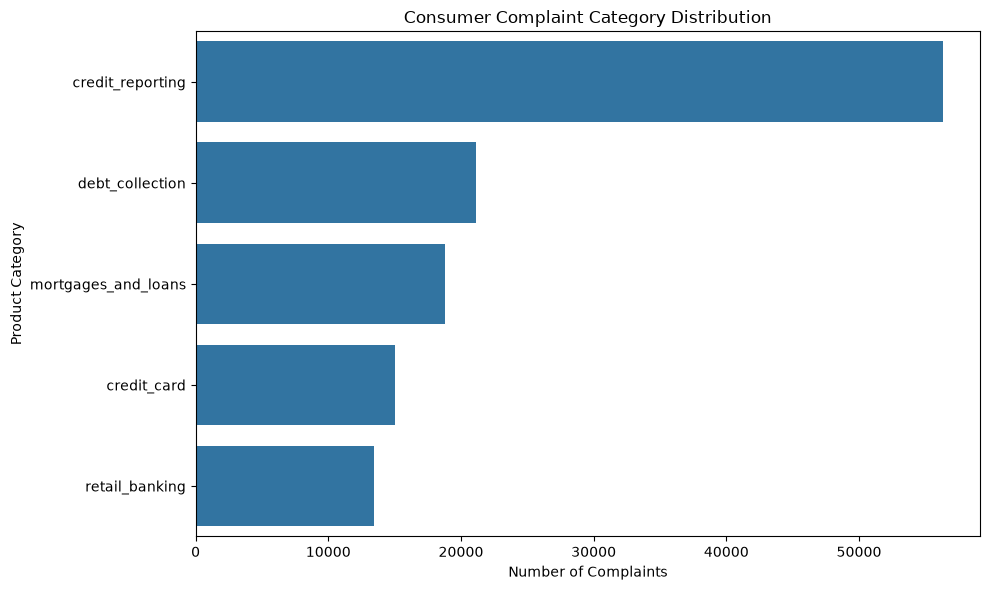

In [21]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="product",
    order=df["product"].value_counts().index
)

plt.title("Consumer Complaint Category Distribution")
plt.xlabel("Number of Complaints")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

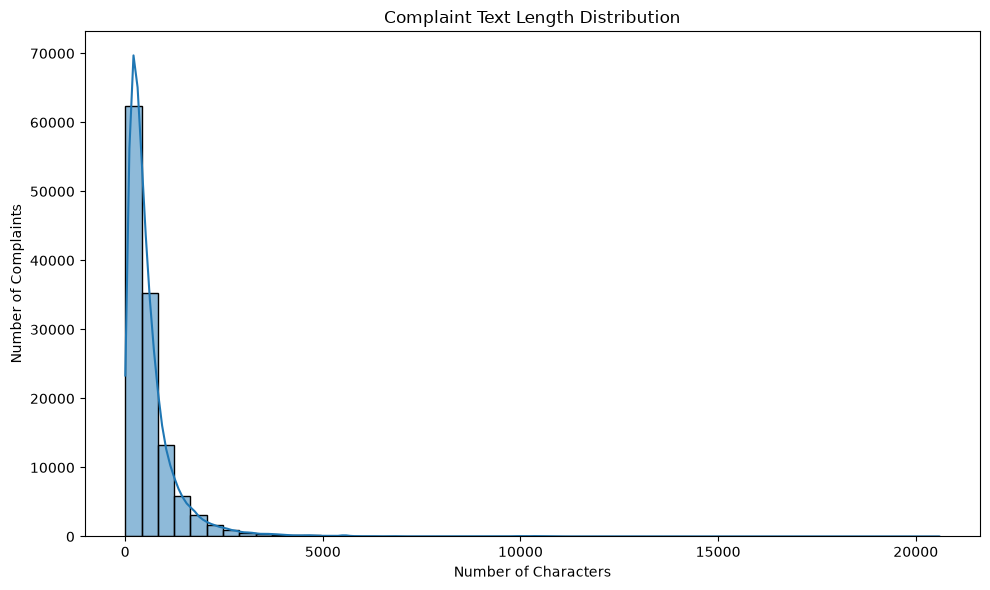

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(df["text_length"], bins=50, kde=True)

plt.title("Complaint Text Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Complaints")
plt.tight_layout()
plt.show()

In [23]:
for category in df["product"].unique():
    print("\n" + "=" * 80)
    print("CATEGORY:", category)
    print("=" * 80)
    
    sample = df[df["product"] == category]["narrative"].iloc[0]
    print(sample)


CATEGORY: credit_card
purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing receive order place due time mask order exact shipping date right however guarantee ship soon soon delivers product u getting small shipment shipping first come first served basis appreciate patience fulfill order quickly recommend keeping order lose place line cancel distributor stock moment prefer cancel please note ask via email cancel accordance cancellation policy agreed checkout electronic inventory online requested order canceled refund issued canceled order sent verification order canceled refunded item particulate respirator refunded subtotal shipping tax total usd visa ending refund called disputed amount stated nothing needed submitted address issue recharged

In [24]:
X = df["narrative"]
y = df["product"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (124676,)
Target: (124676,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 99740
Testing samples: 24936


In [26]:
import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rosha\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rosha\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\rosha\AppData\Roaming\nltk_data...


True

In [27]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    
    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    # Tokenization
    words = text.split()
    
    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)

In [28]:
X_train_processed = X_train.apply(preprocess_text)
X_test_processed = X_test.apply(preprocess_text)

print("Original:")
print(X_train.iloc[0])

print("\nProcessed:")
print(X_train_processed.iloc[0])

Original:
ive homepoint financial since increased mortgage yearly reasoning want bigger buff escrow ive give consideration yearly change ive owned property since never payment first company increasing mortgage yearly two previous one didnt financial time cant afford pay increase yearly would like mortgage assigned another company care client compassion rough time really hope someone take time help would happen dont pay increase asking

Processed:
ive homepoint financial since increased mortgage yearly reasoning want bigger buff escrow ive give consideration yearly change ive owned property since never payment first company increasing mortgage yearly two previous one didnt financial time cant afford pay increase yearly would like mortgage assigned another company care client compassion rough time really hope someone take time help would happen dont pay increase asking


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_processed)
X_test_tfidf = tfidf.transform(X_test_processed)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (99740, 30000)
Testing TF-IDF shape: (24936, 30000)


In [30]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred, average="weighted")
nb_recall = recall_score(y_test, nb_pred, average="weighted")
nb_f1 = f1_score(y_test, nb_pred, average="weighted")

print("Naive Bayes")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Naive Bayes
Accuracy : 0.824711260827719
Precision: 0.8282531457329696
Recall   : 0.824711260827719
F1 Score : 0.8245972384926663


In [31]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average="weighted")
lr_recall = recall_score(y_test, lr_pred, average="weighted")
lr_f1 = f1_score(y_test, lr_pred, average="weighted")

print("Logistic Regression")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression
Accuracy : 0.8476499839589349
Precision: 0.8550251557992755
Recall   : 0.8476499839589349
F1 Score : 0.8490020161063541


In [32]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average="weighted")
svm_recall = recall_score(y_test, svm_pred, average="weighted")
svm_f1 = f1_score(y_test, svm_pred, average="weighted")

print("Linear SVM")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

Linear SVM
Accuracy : 0.8545476419634264
Precision: 0.8561781539994759
Recall   : 0.8545476419634264
F1 Score : 0.8550690648370924


In [33]:
tfidf_rf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_rf = tfidf_rf.fit_transform(X_train_processed)
X_test_rf = tfidf_rf.transform(X_test_processed)

print(X_train_rf.shape)

(99740, 10000)


In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train)

rf_pred = rf_model.predict(X_test_rf)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average="weighted")
rf_recall = recall_score(y_test, rf_pred, average="weighted")
rf_f1 = f1_score(y_test, rf_pred, average="weighted")

print("Random Forest")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest
Accuracy : 0.8518607635547001
Precision: 0.8531441597580627
Recall   : 0.8518607635547001
F1 Score : 0.8522599799240963


In [35]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM",
        "Random Forest"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy,
        svm_accuracy,
        rf_accuracy
    ],
    "Precision": [
        nb_precision,
        lr_precision,
        svm_precision,
        rf_precision
    ],
    "Recall": [
        nb_recall,
        lr_recall,
        svm_recall,
        rf_recall
    ],
    "F1 Score": [
        nb_f1,
        lr_f1,
        svm_f1,
        rf_f1
    ]
})

results.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Linear SVM,0.854548,0.856178,0.854548,0.855069
3,Random Forest,0.851861,0.853144,0.851861,0.852260
1,Logistic Regression,0.847650,0.855025,0.847650,0.849002
0,Naive Bayes,0.824711,0.828253,0.824711,0.824597


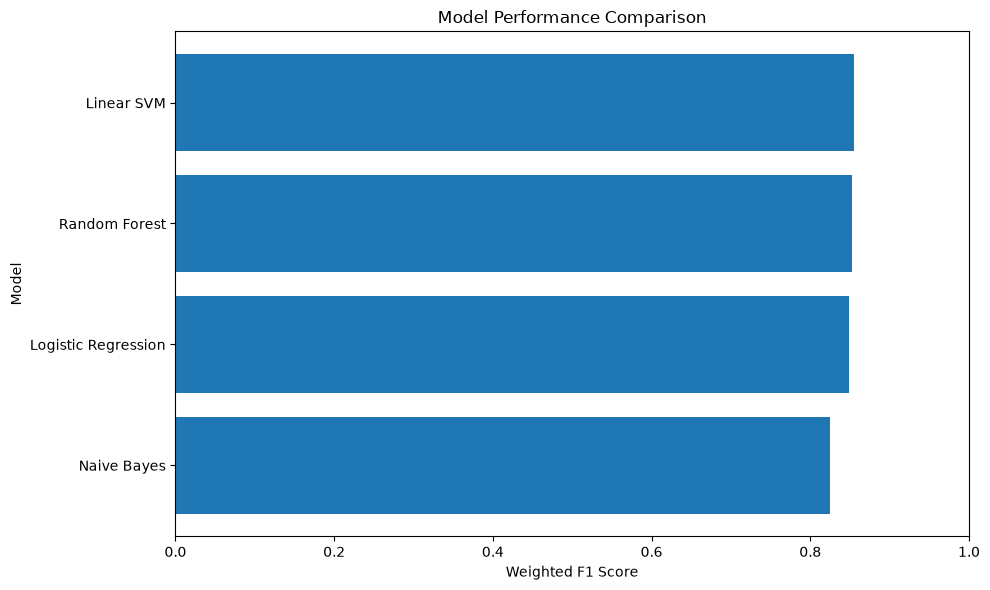

In [36]:
plt.figure(figsize=(10, 6))

results_sorted = results.sort_values("F1 Score", ascending=True)

plt.barh(
    results_sorted["Model"],
    results_sorted["F1 Score"]
)

plt.xlabel("Weighted F1 Score")
plt.ylabel("Model")
plt.title("Model Performance Comparison")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

In [38]:
best_model_name = results.loc[
    results["F1 Score"].idxmax(), "Model"
]

print("Best Model:", best_model_name)
from sklearn.metrics import classification_report

if best_model_name == "Naive Bayes":
    best_pred = nb_pred
    best_model = nb_model

elif best_model_name == "Logistic Regression":
    best_pred = lr_pred
    best_model = lr_model

elif best_model_name == "Linear SVM":
    best_pred = svm_pred
    best_model = svm_model

else:
    best_pred = rf_pred
    best_model = rf_model

print(classification_report(y_test, best_pred))

Best Model: Linear SVM
                     precision    recall  f1-score   support

        credit_card       0.78      0.81      0.80      3005
   credit_reporting       0.91      0.88      0.89     11261
    debt_collection       0.79      0.81      0.80      4223
mortgages_and_loans       0.83      0.85      0.84      3752
     retail_banking       0.85      0.90      0.87      2695

           accuracy                           0.85     24936
          macro avg       0.83      0.85      0.84     24936
       weighted avg       0.86      0.85      0.86     24936



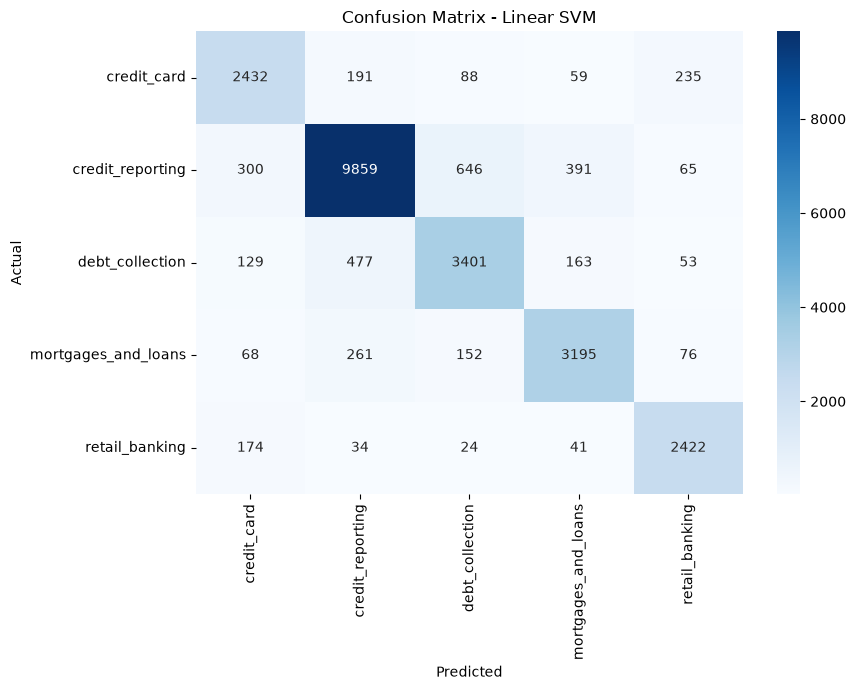

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [40]:
import joblib

joblib.dump(best_model, BASE_DIR / "models" / "complaint_classifier.pkl")
joblib.dump(tfidf, BASE_DIR / "models" / "tfidf_vectorizer.pkl")

print("Best model and TF-IDF vectorizer saved successfully.")

Best model and TF-IDF vectorizer saved successfully.


In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

svm_tuning = LinearSVC(
    class_weight="balanced",
    random_state=42
)

param_grid = {
    "C": [0.5, 1, 1.5, 2]
}

grid_search = GridSearchCV(
    svm_tuning,
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Parameters: {'C': 0.5}
Best CV F1 Score: 0.8566388987029739


In [42]:
tuned_svm = grid_search.best_estimator_

tuned_pred = tuned_svm.predict(X_test_tfidf)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred, average="weighted")
tuned_recall = recall_score(y_test, tuned_pred, average="weighted")
tuned_f1 = f1_score(y_test, tuned_pred, average="weighted")

print("Tuned Linear SVM")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)

Tuned Linear SVM
Accuracy : 0.8576355470003209
Precision: 0.8596659413578195
Recall   : 0.8576355470003209
F1 Score : 0.8582198342112668


In [43]:
best_model = tuned_svm
best_pred = tuned_pred
best_model_name = "Tuned Linear SVM"

print("Final Model:", best_model_name)

Final Model: Tuned Linear SVM


In [44]:
print(classification_report(y_test, best_pred))

                     precision    recall  f1-score   support

        credit_card       0.79      0.83      0.81      3005
   credit_reporting       0.91      0.87      0.89     11261
    debt_collection       0.79      0.81      0.80      4223
mortgages_and_loans       0.83      0.86      0.85      3752
     retail_banking       0.85      0.91      0.88      2695

           accuracy                           0.86     24936
          macro avg       0.84      0.85      0.84     24936
       weighted avg       0.86      0.86      0.86     24936



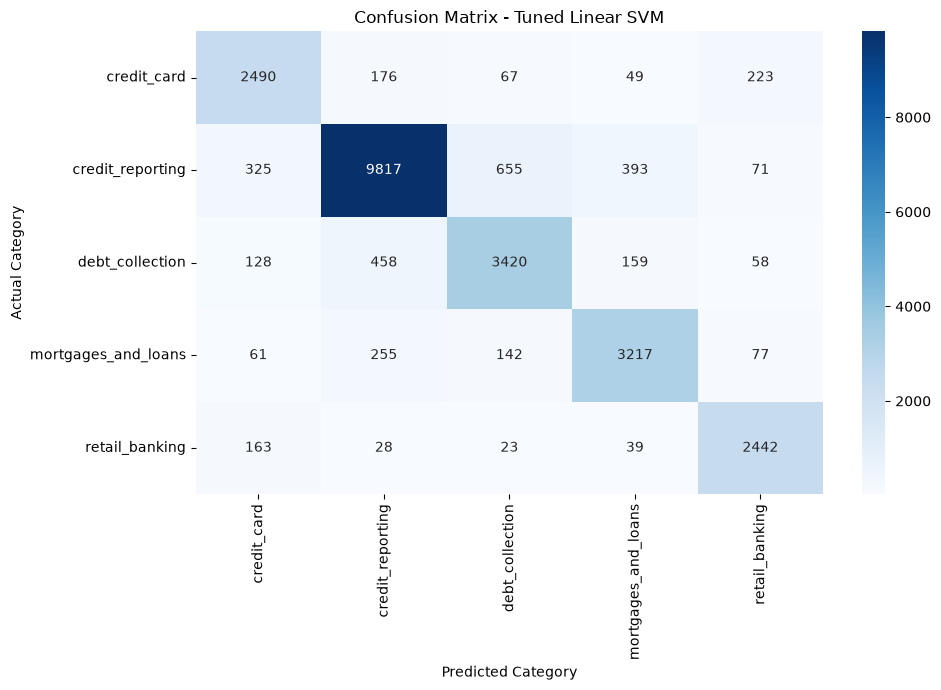

In [45]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.title("Confusion Matrix - Tuned Linear SVM")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.tight_layout()
plt.show()

In [46]:
import joblib

joblib.dump(best_model, BASE_DIR / "models" / "complaint_classifier.pkl")
joblib.dump(tfidf, BASE_DIR / "models" / "tfidf_vectorizer.pkl")

print("Final model saved successfully.")

Final model saved successfully.


In [48]:
def predict_complaint(text):
    processed = preprocess_text(text)
    vector = tfidf.transform([processed])
    prediction = best_model.predict(vector)[0]
    
    return prediction

test_complaints = [
    "My credit card payment is showing incorrectly and I need help.",
    "Someone collected money from my account without my permission.",
    "My credit report contains incorrect information.",
    "I am having problems making my mortgage payment."
]

for complaint in test_complaints:
    print("Complaint:", complaint)
    print("Predicted category:", predict_complaint(complaint))
    print("-" * 80)

Complaint: My credit card payment is showing incorrectly and I need help.
Predicted category: credit_card
--------------------------------------------------------------------------------
Complaint: Someone collected money from my account without my permission.
Predicted category: retail_banking
--------------------------------------------------------------------------------
Complaint: My credit report contains incorrect information.
Predicted category: credit_reporting
--------------------------------------------------------------------------------
Complaint: I am having problems making my mortgage payment.
Predicted category: mortgages_and_loans
--------------------------------------------------------------------------------


In [49]:
!pip install vaderSentiment


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sentiment_analyzer = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    scores = sentiment_analyzer.polarity_scores(str(text))
    
    if scores["compound"] >= 0.05:
        sentiment = "Positive"
    elif scores["compound"] <= -0.05:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"
    
    return sentiment, scores["compound"]

In [51]:
text = "I have been waiting for my refund for several weeks and nobody is helping me."

sentiment, score = analyze_sentiment(text)

print("Sentiment:", sentiment)
print("Sentiment Score:", score)

Sentiment: Positive
Sentiment Score: 0.296


In [52]:
def analyze_complaint(text):
    
    # Category prediction
    processed = preprocess_text(text)
    vector = tfidf.transform([processed])
    category = best_model.predict(vector)[0]
    
    # Sentiment
    sentiment, sentiment_score = analyze_sentiment(text)
    
    # Priority
    text_lower = text.lower()
    
    critical_keywords = [
        "fraud", "stolen", "unauthorized",
        "identity theft", "scam", "emergency"
    ]
    
    high_keywords = [
        "urgent", "immediately", "wrong charge",
        "incorrect", "blocked", "cannot access"
    ]
    
    if any(word in text_lower for word in critical_keywords):
        priority = "Critical"
    elif sentiment == "Negative" and any(word in text_lower for word in high_keywords):
        priority = "High"
    elif sentiment == "Negative":
        priority = "Medium"
    else:
        priority = "Low"
    
    return {
        "Category": category,
        "Sentiment": sentiment,
        "Sentiment Score": round(sentiment_score, 3),
        "Priority": priority
    }

In [53]:
complaint = """
Someone made an unauthorized transaction from my account.
I did not make this transaction and need immediate help.
"""

result = analyze_complaint(complaint)

print(result)

{'Category': 'retail_banking', 'Sentiment': 'Positive', 'Sentiment Score': 0.402, 'Priority': 'Critical'}


In [54]:
joblib.dump(best_model, BASE_DIR / "models" / "complaint_classifier.pkl")
joblib.dump(tfidf, BASE_DIR / "models" / "tfidf_vectorizer.pkl")

print("All ML artifacts saved.")

All ML artifacts saved.
